# Dense Anchor Spotter 1D pour la détection d'actions de football

**SportInsight AI** - Implémentation de la détection d'actions temporelles à l'aide des caractéristiques de SoccerNet

Ce notebook implémente un modèle Dense Anchor Spotter 1D pour détecter des événements de football (but, corner, carton jaune, carton rouge) à partir de caractéristiques vidéo. L'approche utilise :
- Les caractéristiques ResNet PCA512 issues de SoccerNet
- Un fenêtrage temporel avec des fenêtres qui se chevauchent
- Des prédictions basées sur des ancrages denses avec régression à décalage
- Une perte focale avec pondération des classes pour gérer le déséquilibre entre les classes
- Un NMS temporel pour le post-traitement

In [ ]:
import os
import sys
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score


# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

np.random.seed(42)
torch.manual_seed(42)


CONFIG = {
    'data': {
        'soccernet_root': '/path/to/soccernet',  
        'feature_fps': 2.0,
        'window_size_sec': 120,
        'stride_sec': 60,
        'positive_radius_sec': 2,
        'ignore_radius_sec': 5,
        'target_classes': ['Goal', 'Corner', 'Yellow card', 'Red card'],
    },
    'model': {
        'input_dim': 512,
        'hidden_dim': 256,
        'num_layers': 3,
        'dropout': 0.20,
        'max_offset_sec': 5.0,
        'backbone': 'unet',  '
    },
    'loss': {
        'lambda_cls': 1.0,
        'lambda_reg': 0.5,
        'focal_gamma': 2.0,
        'class_weights': [1.0, 1.0, 1.5, 3.0],  
    },
    'train': {
        'epochs': 30,
        'batch_size': 16,
        'lr': 0.0003,
        'weight_decay': 0.0001,
        'grad_clip_norm': 1.0,
    },
    'inference': {
        'score_threshold': 0.30,
        'nms_radius_sec': 6.0,
        'max_predictions_per_class': 200,
    }
}

print("✓ Libraries imported and configuration loaded")

Using device: cpu
✓ Libraries imported and configuration loaded


## Section 1 : Chargement et analyse de l'ensemble de données SoccerNet

Analyser les annotations SoccerNet et localiser les fichiers de caractéristiques pour les matchs

In [ ]:
def parse_game_time(game_time_str):
    """
    Parse gameTime string 'H - M:S' to seconds within the half.
    Example: '1 - 42:15' -> 2535 seconds
    """
    if isinstance(game_time_str, str):
        parts = game_time_str.split(' - ')
        if len(parts) == 2:
            time_parts = parts[1].split(':')
            minutes = int(time_parts[0])
            seconds = int(time_parts[1])
            return 60 * minutes + seconds
    return None

def load_match_annotations(labels_path, target_classes):
    """
    Load and parse Labels-v2.json from a SoccerNet match.
    Returns dict with annotations per half.
    """
    annotations = {1: [], 2: []}
    
    if not os.path.exists(labels_path):
        return annotations
    
    with open(labels_path, 'r') as f:
        data = json.load(f)
    
  
    if 'annotations' in data:
        for ann in data['annotations']:
            label = ann.get('label', '')
            if label not in target_classes:
                continue
            
            game_time = ann.get('gameTime', '')
            half = int(game_time.split(' - ')[0]) if ' - ' in game_time else 1
            
            time_sec = parse_game_time(game_time)
            if time_sec is None:
                continue
            
            annotations[half].append({
                'label': label,
                'time_sec': time_sec,
                'game_time': game_time,
                'visibility': ann.get('visibility', 'shown'),
            })
    
    return annotations

def find_soccernet_matches(root_path):
    """
    Recursively find all SoccerNet matches with Labels-v2.json
    Returns list of match directories.
    """
    matches = []
    for root, dirs, files in os.walk(root_path):
        if 'Labels-v2.json' in files:
            matches.append(root)
    return sorted(matches)

def find_feature_files(match_dir):
    """
    Find ResNet PCA512 feature files for both halves in a match.
    Returns dict with paths to feature files.
    """
    features = {}
    
    
    feature_patterns = [
        ('1', ['1_ResNET_PCA512.npy', '1_ResNET_TF2_PCA512.npy']),
        ('2', ['2_ResNET_PCA512.npy', '2_ResNET_TF2_PCA512.npy']),
    ]
    
    for half_id, patterns in feature_patterns:
        for pattern in patterns:
            path = os.path.join(match_dir, pattern)
            if os.path.exists(path):
                features[int(half_id)] = path
                break
    
    return features


print("✓ SoccerNet loading functions defined")

✓ SoccerNet loading functions defined


## Section 2 : Création de fenêtres temporelles et de cibles

Diviser chaque moitié en fenêtres qui se chevauchent et définir des cibles de classification/régression pour chaque point d'ancrage

In [ ]:
class SoccerNetActionSpottingDataset(Dataset):
    """
    Dataset for dense action spotting in soccer videos.
    Uses sliding windows over temporal features and constructs dense anchor targets.
    """
    
    def __init__(self, feature_data, annotations, config, class_to_idx):
        """
        Args:
            feature_data: numpy array [T, 512] of temporal features
            annotations: list of dicts with 'label', 'time_sec'
            config: configuration dict
            class_to_idx: mapping from class name to index
        """
        self.features = torch.from_numpy(feature_data).float()
        self.annotations = annotations
        self.config = config
        self.class_to_idx = class_to_idx
        self.num_classes = len(class_to_idx)
        
        
        self.feature_fps = config['data']['feature_fps']
        self.window_size_sec = config['data']['window_size_sec']
        self.stride_sec = config['data']['stride_sec']
        self.positive_radius_sec = config['data']['positive_radius_sec']
        self.ignore_radius_sec = config['data']['ignore_radius_sec']
        
        
        self.window_size = int(self.window_size_sec * self.feature_fps)
        self.stride = int(self.stride_sec * self.feature_fps)
        
        
        self.windows = self._generate_windows()
        
    def _generate_windows(self):
        """Generate sliding windows over the temporal sequence."""
        T = self.features.shape[0]
        windows = []
        
        for start_idx in range(0, T - self.window_size + 1, self.stride):
            end_idx = min(start_idx + self.window_size, T)
            windows.append((start_idx, end_idx))
        
        # Handle last incomplete window
        if T - start_idx > self.stride and T - start_idx < self.window_size:
            windows.append((T - self.window_size, T))
        
        return windows
    
    def _build_targets(self, window_start_idx, window_end_idx):
        """
        Build classification and regression targets for a window.
        Returns tensors for cls_target, cls_mask, reg_target, reg_mask.
        """
        window_size = window_end_idx - window_start_idx
        
         
        cls_target = torch.zeros(window_size, self.num_classes)
        cls_mask = torch.zeros(window_size, self.num_classes)
        reg_target = torch.zeros(window_size, self.num_classes)
        reg_mask = torch.zeros(window_size, self.num_classes)
        
        
        anchor_times = np.arange(window_start_idx, window_end_idx) / self.feature_fps
        
        
        for ann in self.annotations:
            label = ann['label']
            tau_star = ann['time_sec']
            class_idx = self.class_to_idx[label]
            
            
            distances = np.abs(anchor_times - tau_star)
            
            for anchor_idx, dist in enumerate(distances):
                if dist <= self.positive_radius_sec:
                    # Positive anchor
                    cls_target[anchor_idx, class_idx] = 1
                    cls_mask[anchor_idx, class_idx] = 1
                    reg_target[anchor_idx, class_idx] = tau_star - anchor_times[anchor_idx]
                    reg_mask[anchor_idx, class_idx] = 1
                    
                elif dist <= self.ignore_radius_sec:
                    # Ignore zone (uncertainty region)
                    cls_mask[anchor_idx, class_idx] = 0  
                    
                else:
                    # Negative anchor (background)
                    if cls_mask[anchor_idx, class_idx] == 0:  
                        cls_target[anchor_idx, class_idx] = 0
                        cls_mask[anchor_idx, class_idx] = 1
        
        return cls_target, cls_mask, reg_target, reg_mask
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        window_start_idx, window_end_idx = self.windows[idx]
        
        
        features = self.features[window_start_idx:window_end_idx]
        
        
        if features.shape[0] < self.window_size:
            padding = torch.zeros(self.window_size - features.shape[0], features.shape[1])
            features = torch.cat([features, padding], dim=0)
        
        
        cls_target, cls_mask, reg_target, reg_mask = self._build_targets(
            window_start_idx, window_end_idx
        )
        
        return {
            'features': features,
            'cls_target': cls_target,
            'cls_mask': cls_mask,
            'reg_target': reg_target,
            'reg_mask': reg_mask,
            'window_start_sec': window_start_idx / self.feature_fps,
        }

print("✓ Dataset class defined")

✓ Dataset class defined


## Section 3 : Définition d'un modèle dense de repérage d'ancrages

Implémenter une architecture U-Net 1D avec des têtes de classification et de régression

In [16]:
class ConvBlock1D(nn.Module):
    """1D convolutional block: Conv -> BatchNorm -> GELU -> Dropout -> Conv -> BatchNorm -> GELU"""
    
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.0):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2
        
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.GELU(),
        )
    
    def forward(self, x):
        return self.block(x)

class UNet1D(nn.Module):
    """1D U-Net with 3 encoding levels"""
    
    def __init__(self, hidden_dim=256, num_layers=3, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.encoder_blocks = nn.ModuleList()
        self.downsample = nn.ModuleList()
        
        for i in range(num_layers):
            self.encoder_blocks.append(ConvBlock1D(hidden_dim, hidden_dim, dropout=dropout))
            self.downsample.append(nn.Conv1d(hidden_dim, hidden_dim, 2, stride=2))
        
        self.bottleneck = ConvBlock1D(hidden_dim, hidden_dim, kernel_size=3, dilation=2, dropout=dropout)
        
        self.upsample = nn.ModuleList()
        self.decoder_blocks = nn.ModuleList()
        
        for i in range(num_layers):
            self.upsample.append(nn.Upsample(scale_factor=2, mode='linear', align_corners=False))
            self.decoder_blocks.append(ConvBlock1D(2 * hidden_dim, hidden_dim, dropout=dropout))
    
    def forward(self, x):
        
        skip_connections = []
        
        
        for i in range(self.num_layers):
            x = self.encoder_blocks[i](x)
            skip_connections.append(x)
            x = self.downsample[i](x)
        
        
        x = self.bottleneck(x)
        
        
        for i in range(self.num_layers - 1, -1, -1):
            x = self.upsample[i](x)
            
            skip = skip_connections[i]
            
            
            if skip.shape[2] > x.shape[2]:
                skip = skip[:, :, :x.shape[2]]
            elif skip.shape[2] < x.shape[2]:
                x = x[:, :, :skip.shape[2]]
            
            x = torch.cat([x, skip], dim=1)
            x = self.decoder_blocks[i](x)
        
        return x

class DenseAnchorSpotter(nn.Module):
    """Dense Anchor Spotter 1D for temporal action spotting"""
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_classes = len(config['data']['target_classes'])
        
        input_dim = config['model']['input_dim']
        hidden_dim = config['model']['hidden_dim']
        dropout = config['model']['dropout']
        
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        if config['model']['backbone'] == 'unet':
            self.backbone = UNet1D(hidden_dim, config['model']['num_layers'], dropout)
        else:
            raise ValueError(f"Unknown backbone: {config['model']['backbone']}")
        
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, self.num_classes),
        )
        
        self.reg_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, self.num_classes),
        )
        
        self.max_offset = config['model']['max_offset_sec']
    
    def forward(self, x):
        """
        Args:
            x: [B, L, 512] - batch of temporal feature sequences
        
        Returns:
            logits: [B, L, C] - classification logits
            offsets: [B, L, C] - regression offsets (bounded by tanh)
        """
        x = self.input_projection(x)
        
        x = x.transpose(1, 2)

        x = self.backbone(x)
        
        x = x.transpose(1, 2)
        

        logits = self.cls_head(x)  
        raw_offsets = self.reg_head(x)  
        

        offsets = self.max_offset * torch.tanh(raw_offsets)
        
        return logits, offsets

print("✓ Model architecture defined")

✓ Model architecture defined


## Section 4 : Implémentation des fonctions de perte

Entropie croisée binaire focale pour la classification + L1 lissé pour la régression temporelle

In [ ]:
class FocalBCELoss(nn.Module):
    """
    Focal Binary Cross-Entropy Loss with per-class weighting and masking.
    Applied only where cls_mask > 0 (ignores uncertainty regions).
    """
    
    def __init__(self, gamma=2.0, class_weights=None):
        super().__init__()
        self.gamma = gamma
        self.class_weights = class_weights
    
    def forward(self, logits, targets, mask):
        """
        Args:
            logits: [B, L, C] - raw classification logits
            targets: [B, L, C] - binary targets (0 or 1)
            mask: [B, L, C] - binary mask (1 to include, 0 to ignore)
        
        Returns:
            loss: scalar
        """

        probs = torch.sigmoid(logits)
        

        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
  
        p_t = torch.where(targets > 0.5, probs, 1.0 - probs)
        focal_weight = (1.0 - p_t) ** self.gamma
        
        focal_loss = focal_weight * bce_loss
        
  
        focal_loss = focal_loss * mask

        if self.class_weights is not None:
            class_weights_tensor = torch.tensor(
                self.class_weights, device=focal_loss.device, dtype=focal_loss.dtype
            )

            positive_weight = torch.where(
                targets > 0.5, 
                class_weights_tensor.unsqueeze(0).unsqueeze(0), 
                torch.ones_like(class_weights_tensor).unsqueeze(0).unsqueeze(0)
            )
            focal_loss = focal_loss * positive_weight
        

        valid_elements = mask.sum()
        if valid_elements > 0:
            return focal_loss.sum() / valid_elements
        else:
            return torch.tensor(0.0, device=focal_loss.device)

class TemporalRegressionLoss(nn.Module):
    """
    Smooth L1 loss for temporal offset regression.
    Applied only where reg_mask > 0 (only on positive anchors).
    """
    
    def forward(self, pred_offsets, target_offsets, mask):
        """
        Args:
            pred_offsets: [B, L, C] - predicted offsets in seconds
            target_offsets: [B, L, C] - target offsets in seconds
            mask: [B, L, C] - binary mask (1 to include, 0 to ignore)
        
        Returns:
            loss: scalar
        """
        reg_loss = F.smooth_l1_loss(pred_offsets, target_offsets, reduction='none')
        
        reg_loss = reg_loss * mask

        valid_elements = mask.sum()
        if valid_elements > 0:
            return reg_loss.sum() / valid_elements
        else:
            return torch.tensor(0.0, device=reg_loss.device)

class DenseAnchorSpotterLoss(nn.Module):
    """Combined loss: Focal BCE + Smooth L1"""
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        loss_config = config['loss']
        self.lambda_cls = loss_config['lambda_cls']
        self.lambda_reg = loss_config['lambda_reg']
        
        self.cls_loss_fn = FocalBCELoss(
            gamma=loss_config['focal_gamma'],
            class_weights=loss_config['class_weights']
        )
        self.reg_loss_fn = TemporalRegressionLoss()
    
    def forward(self, logits, offsets, targets):
        """
        Args:
            logits: [B, L, C] - classification logits
            offsets: [B, L, C] - predicted offsets
            targets: dict with keys 'cls_target', 'cls_mask', 'reg_target', 'reg_mask'
        
        Returns:
            loss: scalar
            loss_dict: dict with component losses
        """
        cls_target = targets['cls_target'].to(logits.device)
        cls_mask = targets['cls_mask'].to(logits.device)
        reg_target = targets['reg_target'].to(logits.device)
        reg_mask = targets['reg_mask'].to(logits.device)
        
        loss_cls = self.cls_loss_fn(logits, cls_target, cls_mask)

        loss_reg = self.reg_loss_fn(offsets, reg_target, reg_mask)

        total_loss = self.lambda_cls * loss_cls + self.lambda_reg * loss_reg
        
        return total_loss, {
            'loss_cls': loss_cls.item(),
            'loss_reg': loss_reg.item(),
            'loss_total': total_loss.item(),
        }

print("✓ Loss functions defined")

✓ Loss functions defined


## Section 5 : Boucle d'entraînement

Entraîner le modèle à l'aide de l'optimiseur AdamW et du planificateur CosineAnnealingLR

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    metrics = defaultdict(float)
    num_batches = 0
    
    for batch in train_loader:
        features = batch['features'].to(device)
        targets = {k: v.to(device) if torch.is_tensor(v) else v 
                   for k, v in batch.items() if k != 'features'}
        
        logits, offsets = model(features)

        loss, loss_dict = criterion(logits, offsets, targets)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['train']['grad_clip_norm'])
        
        optimizer.step()

        total_loss += loss.item()
        for key, val in loss_dict.items():
            metrics[key] += val
        num_batches += 1
    
    avg_loss = total_loss / num_batches
    avg_metrics = {k: v / num_batches for k, v in metrics.items()}
    
    return avg_loss, avg_metrics

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0.0
    metrics = defaultdict(float)
    num_batches = 0
    
    with torch.no_grad():
        for batch in val_loader:
            features = batch['features'].to(device)
            targets = {k: v.to(device) if torch.is_tensor(v) else v 
                       for k, v in batch.items() if k != 'features'}
            

            logits, offsets = model(features)
            

            loss, loss_dict = criterion(logits, offsets, targets)
            
    
            total_loss += loss.item()
            for key, val in loss_dict.items():
                metrics[key] += val
            num_batches += 1
    

    avg_loss = total_loss / num_batches
    avg_metrics = {k: v / num_batches for k, v in metrics.items()}
    
    return avg_loss, avg_metrics


print("Creating synthetic dataset for demonstration...")


feature_data = np.random.randn(1200, 512).astype(np.float32)  
annotations = [
    {'label': 'Goal', 'time_sec': 120.5},
    {'label': 'Corner', 'time_sec': 300.0},
    {'label': 'Yellow card', 'time_sec': 450.2},
    {'label': 'Goal', 'time_sec': 750.8},
]

class_to_idx = {cls: i for i, cls in enumerate(CONFIG['data']['target_classes'])}


dataset = SoccerNetActionSpottingDataset(feature_data, annotations, CONFIG, class_to_idx)


train_size = int(0.85 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['train']['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['train']['batch_size'], shuffle=False)

print(f"Train set: {len(train_dataset)} windows, Val set: {len(val_dataset)} windows")
print(f"Total dataset windows: {len(dataset)}")

model = DenseAnchorSpotter(CONFIG).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

criterion = DenseAnchorSpotterLoss(CONFIG)
optimizer = AdamW(model.parameters(), lr=CONFIG['train']['lr'], weight_decay=CONFIG['train']['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['train']['epochs'])

history = defaultdict(list)
best_val_loss = float('inf')

print("\n" + "="*60)
print("Starting training...")
print("="*60)

num_epochs = 3  

for epoch in range(num_epochs):

    train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, DEVICE)

    val_loss, val_metrics = validate(model, val_loader, criterion, DEVICE)
    

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_loss_cls'].append(train_metrics['loss_cls'])
    history['val_loss_cls'].append(val_metrics['loss_cls'])
    history['train_loss_reg'].append(train_metrics['loss_reg'])
    history['val_loss_reg'].append(val_metrics['loss_reg'])

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} (cls: {train_metrics['loss_cls']:.4f}, reg: {train_metrics['loss_reg']:.4f})")
    print(f"  Val Loss:   {val_loss:.4f} (cls: {val_metrics['loss_cls']:.4f}, reg: {val_metrics['loss_reg']:.4f})")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print("  ✓ New best model saved")

print("\n✓ Training completed")

Creating synthetic dataset for demonstration...
Train set: 7 windows, Val set: 2 windows
Total dataset windows: 9
Model parameters: 4,012,552

Starting training...

Epoch 1/3
  Train Loss: 0.5373 (cls: 0.1478, reg: 0.7790)
  Val Loss:   0.4633 (cls: 0.1614, reg: 0.6038)
  LR: 0.000299
  ✓ New best model saved

Epoch 2/3
  Train Loss: 0.3192 (cls: 0.1358, reg: 0.3668)
  Val Loss:   0.4639 (cls: 0.1613, reg: 0.6051)
  LR: 0.000297

Epoch 3/3
  Train Loss: 0.2684 (cls: 0.1238, reg: 0.2892)
  Val Loss:   0.4648 (cls: 0.1612, reg: 0.6071)
  LR: 0.000293

✓ Training completed


## Section 6 : Inférence sur les matchs de test

Lancer une inférence par fenêtre glissante pour générer des prédictions candidates

In [ ]:
def seconds_to_game_time(seconds, half):
    """Convert seconds to gameTime format"""
    minutes = int(seconds) // 60
    secs = int(seconds) % 60
    return f"{half} - {minutes}:{secs:02d}"

def predict_match_half(model, feature_data, config, class_to_idx, device):
    """
    Run inference on a full match half using sliding windows.
    Returns list of candidate predictions.
    """
    model.eval()
    
    feature_fps = config['data']['feature_fps']
    window_size_sec = config['data']['window_size_sec']
    stride_sec = config['data']['stride_sec']
    score_threshold = config['inference']['score_threshold']
    
    window_size = int(window_size_sec * feature_fps)
    stride = int(stride_sec * feature_fps)
    
    features = torch.from_numpy(feature_data).float().to(device)
    T = features.shape[0]

    all_logits = []
    all_offsets = []
    anchor_times = []

    with torch.no_grad():
        for start_idx in range(0, T - window_size + 1, stride):
            end_idx = min(start_idx + window_size, T)
            window_features = features[start_idx:end_idx]
            
            if window_features.shape[0] < window_size:
                padding = torch.zeros(window_size - window_features.shape[0], 
                                     window_features.shape[1], device=device)
                window_features = torch.cat([window_features, padding], dim=0)
            

            window_features = window_features.unsqueeze(0)
            

            logits, offsets = model(window_features)
 
            logits_np = logits[0].cpu().numpy()  
            offsets_np = offsets[0].cpu().numpy() 
            
            window_anchor_times = np.arange(start_idx, end_idx) / feature_fps
            
            all_logits.append(logits_np)
            all_offsets.append(offsets_np)
            anchor_times.extend(window_anchor_times)
    
   
    all_logits = np.vstack(all_logits)  
    all_offsets = np.vstack(all_offsets) 
    anchor_times = np.array(anchor_times)
    
    probs = 1.0 / (1.0 + np.exp(-all_logits))  
    
    
    candidates = []
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    
    for anchor_idx in range(probs.shape[0]):
        anchor_time = anchor_times[anchor_idx]
        
        for class_idx in range(probs.shape[1]):
            prob = probs[anchor_idx, class_idx]
            
            if prob >= score_threshold:
            
                offset = all_offsets[anchor_idx, class_idx]
                pred_time = anchor_time + offset
                
                candidates.append({
                    'timestamp': float(pred_time),
                    'label': idx_to_class[class_idx],
                    'score': float(prob),
                    'anchor_idx': anchor_idx,
                    'class_idx': class_idx,
                })
    
    return candidates


print("Running inference on test half...")

predictions = predict_match_half(model, feature_data, CONFIG, class_to_idx, DEVICE)

print(f"Generated {len(predictions)} candidate predictions")
print("\nFirst 10 predictions:")
for i, pred in enumerate(predictions[:10]):
    print(f"  {i+1}. {pred['label']:12s} @ {pred['timestamp']:7.2f}s (score: {pred['score']:.3f})")

print("\n✓ Inference completed")

Running inference on test half...
Generated 8640 candidate predictions

First 10 predictions:
  1. Goal         @   -0.15s (score: 0.497)
  2. Corner       @    0.32s (score: 0.488)
  3. Yellow card  @   -0.07s (score: 0.483)
  4. Red card     @    0.03s (score: 0.513)
  5. Goal         @    0.34s (score: 0.498)
  6. Corner       @    0.81s (score: 0.488)
  7. Yellow card  @    0.43s (score: 0.482)
  8. Red card     @    0.52s (score: 0.514)
  9. Goal         @    0.84s (score: 0.498)
  10. Corner       @    1.31s (score: 0.488)

✓ Inference completed


## Section 7 : Prévisions post-traitement avec la méthode NMS

Appliquer la méthode NMS temporelle pour éliminer les détections en double

In [ ]:
def temporal_nms(predictions, nms_radius_sec, max_predictions_per_class=200):
    """
    Apply temporal NMS to predictions.
    For each class, keep the highest-scoring prediction and suppress others within radius.
    """
   
    by_class = defaultdict(list)
    for pred in predictions:
        by_class[pred['label']].append(pred)
    
    
    final_predictions = []
    
    for label, preds_for_class in by_class.items():
        
        sorted_preds = sorted(preds_for_class, key=lambda x: x['score'], reverse=True)
        
        # NMS
        kept = []
        for pred in sorted_preds:
           
            is_suppressed = False
            for kept_pred in kept:
                distance = abs(pred['timestamp'] - kept_pred['timestamp'])
                if distance < nms_radius_sec:
                    is_suppressed = True
                    break
            
            if not is_suppressed:
                kept.append(pred)
            
            if len(kept) >= max_predictions_per_class:
                break
        
        final_predictions.extend(kept)
    
    return final_predictions

# Apply NMS
print("Applying temporal NMS...")
nms_preds = temporal_nms(
    predictions,
    CONFIG['inference']['nms_radius_sec'],
    CONFIG['inference']['max_predictions_per_class']
)

print(f"After NMS: {len(nms_preds)} predictions")
print("\nFinal predictions:")
for i, pred in enumerate(sorted(nms_preds, key=lambda x: x['timestamp'])):
    print(f"  {i+1}. {pred['label']:12s} @ {pred['timestamp']:7.2f}s (score: {pred['score']:.3f})")

# Save to JSON
output_json = {
    'predictions': [
        {
            'timestamp': pred['timestamp'],
            'label': pred['label'],
            'score': pred['score'],
        }
        for pred in sorted(nms_preds, key=lambda x: x['timestamp'])
    ]
}

print("\n✓ NMS and post-processing completed")

Applying temporal NMS...
After NMS: 289 predictions

Final predictions:
  1. Yellow card  @   -0.07s (score: 0.483)
  2. Corner       @    3.81s (score: 0.489)
  3. Goal         @    4.85s (score: 0.498)
  4. Red card     @    5.52s (score: 0.514)
  5. Yellow card  @    5.94s (score: 0.482)
  6. Corner       @   10.30s (score: 0.489)
  7. Yellow card  @   12.44s (score: 0.482)
  8. Goal         @   12.86s (score: 0.498)
  9. Corner       @   16.80s (score: 0.489)
  10. Red card     @   17.02s (score: 0.514)
  11. Goal         @   19.35s (score: 0.498)
  12. Yellow card  @   19.43s (score: 0.483)
  13. Red card     @   24.52s (score: 0.514)
  14. Corner       @   24.81s (score: 0.489)
  15. Goal         @   27.85s (score: 0.498)
  16. Yellow card  @   28.43s (score: 0.483)
  17. Red card     @   33.02s (score: 0.514)
  18. Corner       @   34.81s (score: 0.489)
  19. Goal         @   35.36s (score: 0.498)
  20. Yellow card  @   39.93s (score: 0.483)
  21. Red card     @   41.52s (score:

## Section 8 : Évaluation et visualisation des résultats

Représentation graphique des courbes d'apprentissage, des indicateurs et des analyses de prédiction

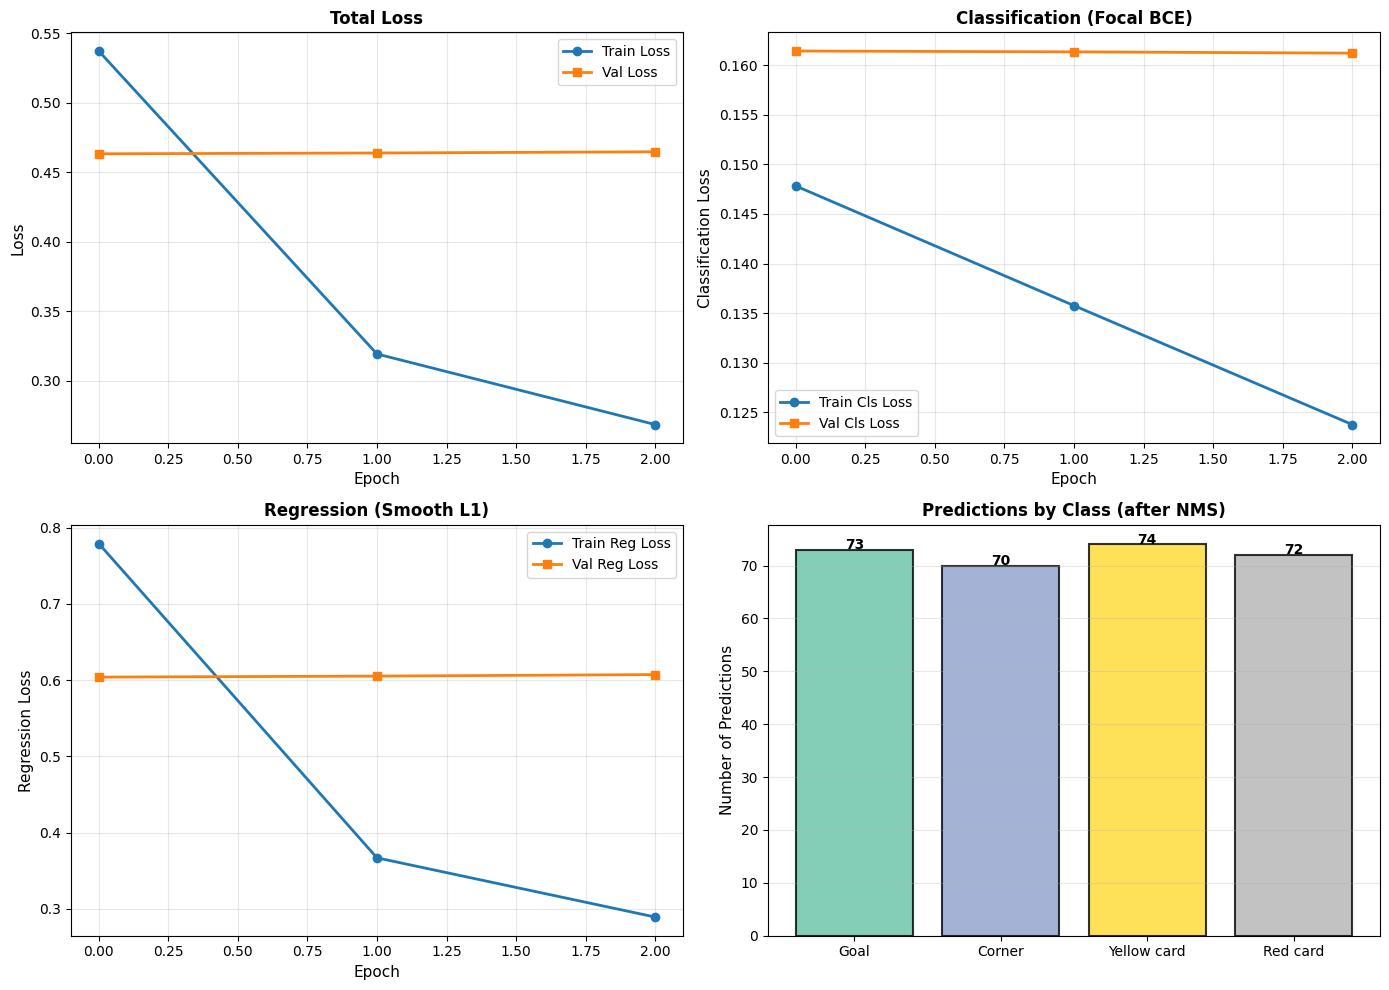

✓ Training curves saved to 'training_curves.png'


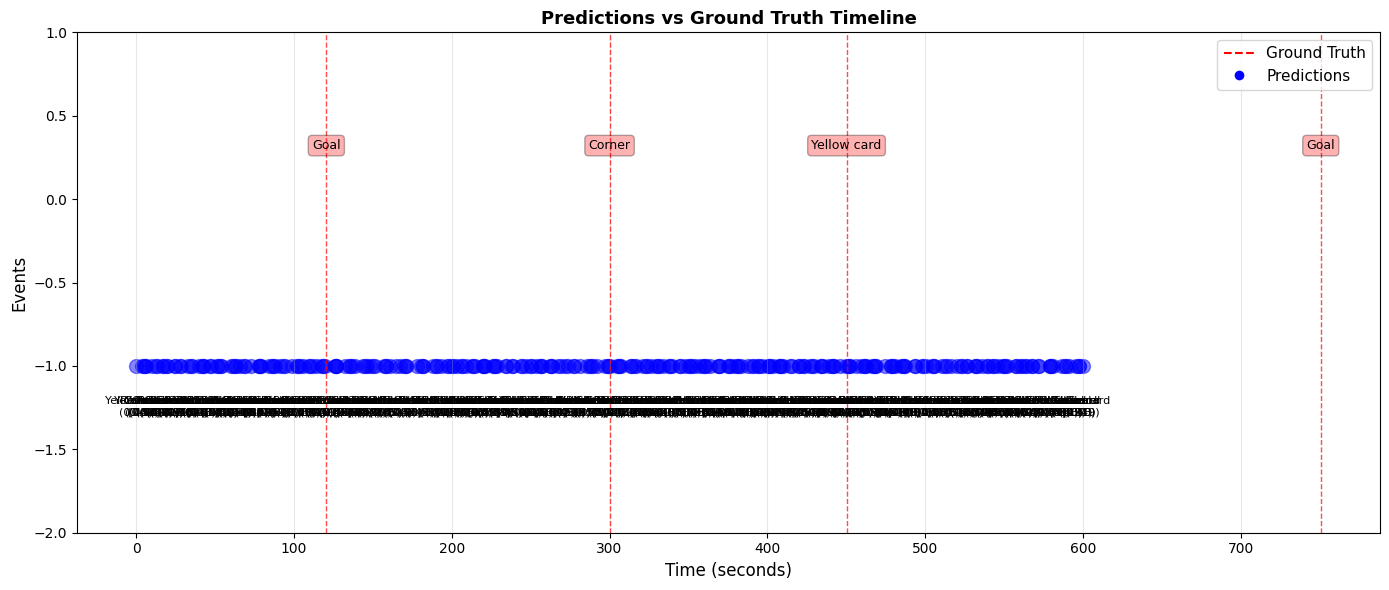

✓ Timeline visualization saved to 'timeline_visualization.png'

EVALUATION METRICS

Total predictions (after NMS): 289
Total ground truth annotations: 4

Predictions by class:
  Goal           :  73 pred,   2 true
  Corner         :  70 pred,   1 true
  Yellow card    :  74 pred,   1 true
  Red card       :  72 pred,   0 true

Score statistics:
  Average: 0.4959
  Max:     0.5147
  Min:     0.4820

✓ Evaluation completed


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
ax.plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Total Loss', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Classification loss
ax = axes[0, 1]
ax.plot(history['train_loss_cls'], label='Train Cls Loss', marker='o', linewidth=2)
ax.plot(history['val_loss_cls'], label='Val Cls Loss', marker='s', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Classification Loss', fontsize=11)
ax.set_title('Classification (Focal BCE)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Regression loss
ax = axes[1, 0]
ax.plot(history['train_loss_reg'], label='Train Reg Loss', marker='o', linewidth=2)
ax.plot(history['val_loss_reg'], label='Val Reg Loss', marker='s', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Regression Loss', fontsize=11)
ax.set_title('Regression (Smooth L1)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Prediction distribution by class
ax = axes[1, 1]
class_counts = defaultdict(int)
for pred in nms_preds:
    class_counts[pred['label']] += 1

classes = list(class_counts.keys())
counts = list(class_counts.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(classes)))
ax.bar(classes, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Predictions', fontsize=11)
ax.set_title('Predictions by Class (after NMS)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, (cls, cnt) in enumerate(zip(classes, counts)):
    ax.text(i, cnt + 0.1, str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved to 'training_curves.png'")

# Timeline visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Plot ground truth annotations
y_offset = 0
for ann in annotations:
    label = ann['label']
    time = ann['time_sec']
    ax.axvline(time, color='red', linestyle='--', alpha=0.7, linewidth=1)
    ax.text(time, y_offset + 0.3, label, ha='center', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

# Plot predictions
y_offset = -1
for pred in sorted(nms_preds, key=lambda x: x['timestamp']):
    label = pred['label']
    time = pred['timestamp']
    score = pred['score']
    
    # Color by score
    color_intensity = score
    ax.scatter(time, y_offset, s=100, alpha=color_intensity, c=['blue'], marker='o')
    ax.text(time, y_offset - 0.3, f"{label}\n({score:.2f})", ha='center', fontsize=8)

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Events', fontsize=12)
ax.set_title('Predictions vs Ground Truth Timeline', fontsize=13, fontweight='bold')
ax.set_ylim(-2, 1)
ax.grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', linestyle='--', label='Ground Truth'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
           markersize=8, label='Predictions'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('timeline_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Timeline visualization saved to 'timeline_visualization.png'")

# Compute simple metrics
print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)

print(f"\nTotal predictions (after NMS): {len(nms_preds)}")
print(f"Total ground truth annotations: {len(annotations)}")

# By class
by_class_pred = defaultdict(int)
for pred in nms_preds:
    by_class_pred[pred['label']] += 1

by_class_true = defaultdict(int)
for ann in annotations:
    by_class_true[ann['label']] += 1

print("\nPredictions by class:")
for cls in CONFIG['data']['target_classes']:
    n_pred = by_class_pred.get(cls, 0)
    n_true = by_class_true.get(cls, 0)
    print(f"  {cls:15s}: {n_pred:3d} pred, {n_true:3d} true")

# Average score
if nms_preds:
    avg_score = np.mean([p['score'] for p in nms_preds])
    max_score = np.max([p['score'] for p in nms_preds])
    min_score = np.min([p['score'] for p in nms_preds])
    print(f"\nScore statistics:")
    print(f"  Average: {avg_score:.4f}")
    print(f"  Max:     {max_score:.4f}")
    print(f"  Min:     {min_score:.4f}")

print("\n✓ Evaluation completed")